# SANS analysis II: Priors and statistics 

You have now [simulated](./../3-mcstas/mcstas-sans.ipynb), [reduced](./../4-reduction/reduction-sans.ipynb), and carried out [routine analysis of your SANS data](analysis-sans.ipynb).

This notebook builds on the previous by beginning to look at model fitting [probabilistically](./prob_data.ipynb), including prior knowledge about the system or parameters under study in the analysis. 

We will continue with the same dataset. 

In [1]:
import numpy as np
import utils

As before, we can load in our simulated (or example) dataset and check it looks correct:

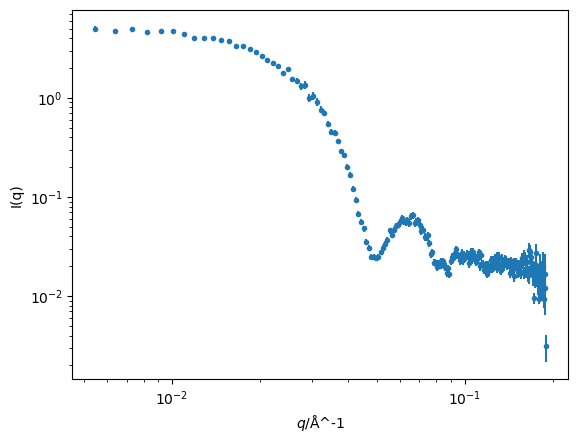

In [4]:
filename = utils.fetch_data("4-reduction/sans_iofq.dat")
#filename = '../4-reduction/sans_iofq.dat'


import matplotlib.pyplot as plt
q, i, di = utils.load(filename)
fig, ax = plt.subplots()
ax.errorbar(q, i, di, fmt='.')
ax.set(yscale='log', xscale='log', xlabel='$q$/Å^-1', ylabel='I(q)')
plt.show()

Now we can load in sans-fitter and initialise it with the same sphere model as before:

In [2]:
from sans_fitter import SANSFitter
fitter = SANSFitter()
fitter.load_data(filename)
fitter.set_model('sphere')
fitter.get_params()

NameError: name 'filename' is not defined

By default, some parameters are set but nothing is allowed to vary. Obviously, this will constrain our fitting algorithm excessively. 

In the previous example, we have included prior knowledge in the analysis through the use of bounded parameters. 

Bounded parameters cannot have values less than some lower bound (Min) or greater than some upper bound (Max), as the probability of the parameters having these values is zero. 
For example, if the parameter `b` from a quadratic model has bounds of 0 and 10, then there is an equal probability that the value of `b` can be anything in between 0 and 10, and a probability of 0 outside those bounds, i.e., it has a uniform prior probability distribution ({numref}`uniform`).

## Exercise 1: Provide some sensible bounds for the data, and confirm the input:

In [19]:
fitter.set_param('sld', value=3, min=1, max=30, vary=False)
fitter.set_param('sld_solvent', value=6, min=1, max=30, vary=False)

fitter.set_param('radius', value=80, min=10, max=300, vary=True)
fitter.set_param('scale', value=1.4e-7, min=0, max=1, vary=True)
fitter.set_param('background', value=0.1, min=0, max=1, vary=True)

fitter.get_params()


Model: sphere
Parameter            Value        Min          Max          Vary    
--------------------------------------------------------------------------------
sld                  3            1            30           ✗       
sld_solvent          6            1            30           ✗       
radius               80           10           300          ✓       
scale                1.4e-07      0            1            ✓       
background           0.1          0            1            ✓       



Great: Now the model is set up, let's introduce some new syntax for $Bayesian$ analysis using `sans-fitter`. 

`SasView`, and hence `sans-fitter`, have a number of optimisation algorithms built-in. One of these is `DREAM`, a population based algorithm. 

`DREAM` is relatively slow; it follows a differential evolution-like process but sometimes keeps individuals which get worse with the evolution and allows these to progress as a Markov chain which converges on the equilibrium distribution, where the chain draws randomly from the posterior distribution. 

Therefore, we can use the `DREAM` fitting algorithm to determine parameter uncertainties from our fitting process. 

[More can be read about `DREAM` in the associated publication](https://www.degruyterbrill.com/document/doi/10.1515/IJNSNS.2009.10.3.273/html), or in the [SasView documentation](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/optimizer.html#fit-dream). 

We will begin by setting a few parameters: `samples` (number of points to be drawn from the Markov chain) and `burn` (number of iterations for the Markov chain to converge to the equilibrium distribution).

To estimate the 68% interval to two digits of precision, at least 1e5 (or 100,000) samples are needed. For the 95% interval, 1e6 (or 1,000,000) samples are needed. 1e4 samples gives a 'quick-and-dirty' approximation of the uncertainty. 

In [25]:
result = fitter.fit_bayesian(samples=10000, burn=100)


Initial χ² = 3.7706
Sampling posterior with BUMPS DREAM (samples=10000, burn=100 generations)...

✓ Fit completed!
Final χ² = 3.7700

Fitted parameters:
  background: 0.01862(19)
  radius: 90.62(14)
  scale: 0.001929(14)

Posterior summary:
Parameter                    Best         Mean       Median          Std                     68% CI                     95% CI
------------------------------------------------------------------------------------------------------------------------------
background              0.0186216    0.0186008    0.0186039  0.000188338       [0.0184075, 0.01879]     [0.0182386, 0.0189669]
radius                    90.6159       90.615      90.6109     0.140741          [90.4743, 90.757]         [90.3472, 90.8929]
scale                  0.00192887   0.00192946   0.00192904  1.36442e-05   [0.00191593, 0.00194313]   [0.00190268, 0.00195648]

Parameter                 R-hat        ESS
------------------------------------------
background               1.0211     

/Users/oliverhammond/miniforge3/lib/python3.13/site-packages/bumps/fitproblem.py:402: UserWarning: Deprecated: use of problem.fitness will be removed at some point
  warnings.warn("Deprecated: use of problem.fitness will be removed at some point")


We can plot the fit and residuals as before: 

In [28]:
fitter.plot_results(show_residuals=True, log_scale=True)

We can now look at the fitting output in detail using a variety of plots:


i. A 'corner' plot showing a grid of parameter distribution from the Bayesian multi-parameter analysis.

ii. A marginal posterior plot showing the probability distribution for a single, chosen parameter.

iii. A Bayesian posterior predictive 95% credible band plot, which displays the model's predicted outcomes over a range of inputs (shaded region may be invisible depending on constraints).

iv. A parameter heatmap giving a colour-coded grid of relationships and statistical dependencies between model parameters estimated from Bayesian inference.

v. The Markov chain Monte Carlo (MCMC) trace which demonstrates how all of the parameters evolved during the fit.

In [27]:
print('\nGenerating posterior pair (corner) plot...')
fitter.plot_posterior_pairs()


Generating posterior pair (corner) plot...


In [22]:
print('\nGenerating marginal posterior for radius...')
fitter.plot_param_distribution('radius')


Generating marginal posterior for radius...


In [ ]:
print('\nGenerating posterior predictive band...')
fitter.plot_posterior_predictive(style='band')


Generating posterior predictive band...


In [23]:
print('\nGenerating parameter correlation heatmap...')
fitter.plot_param_correlations()


Generating parameter correlation heatmap...


In [24]:
print('\nGenerating MCMC trace plot...')
fitter.plot_trace()


Generating MCMC trace plot...


Finally, an example of how one can access the posterior data and save the fit results:

In [31]:
posterior = fitter.get_posterior()
print('\nSampled parameters:', posterior.labels)
print('Chain shape:', posterior.samples.shape)
print('95% credible intervals:')
for name in posterior.labels:
    low, high = posterior.ci_95[name]
    print(f'  {name}: [{low:.6g}, {high:.6g}]')

# Export the raw chain for external analysis (pandas, corner, arviz, ...)
posterior.save_posterior_csv('posterior_chain.csv')
print('\n✓ Raw posterior chain saved to posterior_chain.csv')

# The saved fit results include the credible intervals in the header
fitter.save_results('bayesian_fit_results.csv')



Sampled parameters: ['background', 'radius', 'scale']
Chain shape: (8130, 3)
95% credible intervals:
  background: [0.0182386, 0.0189669]
  radius: [90.3472, 90.8929]
  scale: [0.00190268, 0.00195648]

✓ Raw posterior chain saved to posterior_chain.csv
✓ Results saved to bayesian_fit_results.csv


## Exercise 2: Explore models for the data

You are now armed with knowledge of how to choose models, set variable and fixed parameters and constraints, and to fit data with straightforward and more statistically rigorous approaches.

The available `SasView` models can be found [here](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/models/index.html). Pick one, or several, and see how they perform for this dataset.

In the previous notebook we explored ellipsoidal vs. spherical fits for this dataset. Are you now able to distinguish between the two? Does Bayesian analysis help? 

In [8]:
from sans_fitter import SANSFitter
filename = utils.fetch_data("4-reduction/sans_iofq.dat")

fitteri = SANSFitter()
fitteri.load_data(filename)
fitteri.set_model('cylinder')
fitteri.get_params()

✓ Loaded data from /Users/oliverhammond/Library/Caches/dmsc_school/4-reduction/sans_iofq.dat
  Q range: 0.0055 to 0.1895 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'cylinder' loaded successfully
  Available parameters: 8

Model: cylinder
Parameter            Value        Min          Max          Vary    
--------------------------------------------------------------------------------
sld                  4            0            40           ✗       
sld_solvent          1            0            10           ✗       
radius               20           0            200          ✗       
length               400          0            4000         ✗       
theta                60           -360         360          ✗       
phi                  60           -360         360          ✗       
scale                1            0            inf          ✗       
background           0            0            inf          ✗       



In [10]:
fitteri.set_param('sld', value=3, min=1, max=30, vary=False)
fitteri.set_param('sld_solvent', value=6, min=1, max=30, vary=False)

fitteri.set_param('radius', value=80, min=10, max=300, vary=True)
fitteri.set_param('length', value=80, min=10, max=300, vary=True)

fitteri.set_param('scale', value=1.4e-7, min=0, max=1, vary=True)
fitteri.set_param('background', value=0.1, min=0, max=1, vary=True)

fitteri.get_params()


Model: cylinder
Parameter            Value        Min          Max          Vary    
--------------------------------------------------------------------------------
sld                  3            1            30           ✗       
sld_solvent          6            1            30           ✗       
radius               80           10           300          ✓       
length               80           10           300          ✓       
theta                60           -360         360          ✗       
phi                  60           -360         360          ✗       
scale                1.4e-07      0            1            ✓       
background           0.1          0            1            ✓       



In [15]:
result = fitteri.fit_bayesian(samples=10000, burn=100)
fitteri.plot_results(show_residuals=True, log_scale=True)


Initial χ² = 3.5291
Sampling posterior with BUMPS DREAM (samples=10000, burn=100 generations)...

✓ Fit completed!
Final χ² = 3.5291

Fitted parameters:
  background: 0.01662(20)
  length: 141.4(1.2)
  radius: 82.93(39)
  scale: 0.001974(15)

Posterior summary:
Parameter                    Best         Mean       Median          Std                     68% CI                     95% CI
------------------------------------------------------------------------------------------------------------------------------
background              0.0166181    0.0166256    0.0166162  0.000198732     [0.0164312, 0.0168257]     [0.0162171, 0.0170086]
length                    141.361      141.641      141.558      1.25661         [140.427, 142.878]         [139.323, 144.157]
radius                    82.9337      82.8493        82.87     0.388308          [82.4645, 83.245]         [82.0699, 83.5644]
scale                  0.00197401   0.00197453   0.00197397  1.49363e-05   [0.00195982, 0.00198946]   

/Users/oliverhammond/miniforge3/lib/python3.13/site-packages/bumps/fitproblem.py:402: UserWarning: Deprecated: use of problem.fitness will be removed at some point
  warnings.warn("Deprecated: use of problem.fitness will be removed at some point")


In [16]:
print('\nGenerating posterior pair (corner) plot...')
fitteri.plot_posterior_pairs()


Generating posterior pair (corner) plot...
